In [2]:
import sys 
import os 
sys.path.append('/volume_4/research/seongbong/flywire/geosmin_project_version_update/code')
from analysis_of_simulation_result import * 
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 10

atGRN_cluster = pd.read_parquet('/volume_4/research/seongbong/flywire/geosmin_project_version_update/data/atGRN_cluster_info_v783.parquet')
labial_cluster = pd.read_parquet('/volume_4/research/seongbong/flywire/geosmin_project_version_update/data/labial_cluster_info_v783.parquet')


In [3]:
path = f'{os.getcwd()}/tarsal/result'
df_mn9_per_type_tarsal = {}
std_per_type_tarsal = {}
for g in os.listdir(path):
    this_path = f'{path}/{g}'
    suc_cond = [x for x in os.listdir(this_path) if '.parquet' in x]
    suc_cond_path = [f'{this_path}/{fname}' for fname in suc_cond]
    rate_suc,spike_suc,std_suc =  read_result_with_multi_thread(suc_cond_path,mn9,'MN9')
    df_mn9_per_type_tarsal[g]= pd.concat(rate_suc,axis=1)
    std_per_type_tarsal[g] = pd.concat(std_suc,axis=1)/np.sqrt(100)

100%|████████████████████████████████████████| 11/11 [00:00<00:00, 28944.38it/s]


In [5]:
path = f'{os.getcwd()}/labial/result'
df_mn9_per_type_labial = {}
std_per_type_labial = {}
for g in os.listdir(path):
    this_path = f'{path}/{g}'
    suc_cond = [x for x in os.listdir(this_path) if '.parquet' in x]
    suc_cond_path = [f'{this_path}/{fname}' for fname in suc_cond]
    rate_suc,spike_suc,std_suc =  read_result_with_multi_thread(suc_cond_path,mn9,'MN9')
    df_mn9_per_type_labial[g] = pd.concat(rate_suc,axis=1)
    std_per_type_labial[g]= pd.concat(std_suc,axis=1)/np.sqrt(100)

100%|████████████████████████████████████████| 11/11 [00:00<00:00, 77411.65it/s]


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

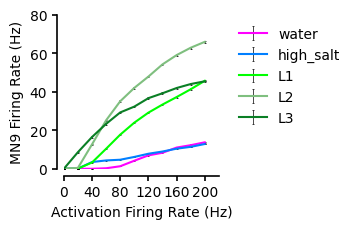

In [30]:
colors_wanted = list(dict.fromkeys(labial_cluster.color))
type_name = list(dict.fromkeys(labial_cluster.type))

df_mn9 = pd.concat(list(df_mn9_per_type_labial.values()))
std_mn9 = pd.concat(list(std_per_type_labial.values()))
df_mn9.index = list(df_mn9_per_type_labial.keys())
std_mn9.index = list(std_per_type_labial.keys())
colors = [colors_wanted[type_name.index(g)] for g in df_mn9.index]


fig, ax = plt.subplots(1,1, figsize=(2,2))

for i, g in enumerate(df_mn9.index):

    y = df_mn9.loc[g].values.astype(float)

    # 에러 계산 방법 선택
    yerr = std_mn9.loc[g].values

    ax.errorbar(
        df_mn9.columns,
        y,
        yerr=yerr,                 # 실제 에러가 있다면 여기에
        color=colors[i],
        capsize=1,
        ecolor='black',
        label=g,
        elinewidth=.5,
        capthick=.5,
#         linewidth=1
    )

ax.set_ylim([0,80])
ax.set_xlim([0,10])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.tick_params(axis='both', width=1.2)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_linewidth(1.2)
ax.set_xticks(list(range(0,11,2)), list(range(0,240,40)))
ax.set_xlabel('Activation Firing Rate (Hz)')
ax.set_ylabel('MN9 Firing Rate (Hz)')
ax.legend(loc=2,bbox_to_anchor=(1.05,1),frameon=False)
ax.set_xlim([0,11])
plt.savefig('fig4d_labial_each_type_stimulation.svg',bbox_inches='tight')

In [14]:
pwd

'/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure4/each_type_stimulation'

In [10]:
df_mn9.to_excel('Labellar_candidate_stimulation.xlsx')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

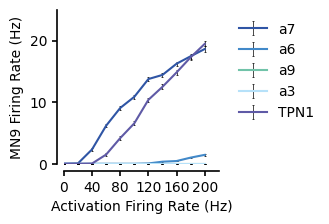

In [31]:
colors_wanted = list(dict.fromkeys(atGRN_cluster.color))
colors_wanted.append('#5f5aa6')
type_name = list(dict.fromkeys(atGRN_cluster.type))
type_name.append('TPN1')

df_mn9 = pd.concat(list(df_mn9_per_type_tarsal.values()))
std_mn9 = pd.concat(list(std_per_type_tarsal.values()))
df_mn9.index = list(df_mn9_per_type_tarsal.keys())
std_mn9.index = list(std_per_type_tarsal.keys())
colors = [colors_wanted[type_name.index(g)] for g in df_mn9.index]
colors.append('#5f5aa6')

fig, ax = plt.subplots(1,1, figsize=(2,2))

for i, g in enumerate(df_mn9.index):

    y = df_mn9.loc[g].values.astype(float)

    # 에러 계산 방법 선택
    yerr = std_mn9.loc[g].values

    ax.errorbar(
        df_mn9.columns,
        y,
        yerr=yerr,                 # 실제 에러가 있다면 여기에
        color=colors[i],
        capsize=1,
        ecolor='black',
        label=g,
        elinewidth=.5,
        capthick=.5,
#         linewidth=1
    )
ax.set_yticks(list(range(0,30,10)))
ax.set_ylim([0,25])
ax.set_xlim([0,10])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.tick_params(axis='both', width=1.2)

ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_linewidth(1.2)
ax.set_xticks(list(range(0,11,2)), list(range(0,240,40)))
ax.set_xlabel('Activation Firing Rate (Hz)')
ax.set_ylabel('MN9 Firing Rate (Hz)')
ax.legend(loc=2,bbox_to_anchor=(1.05,1),frameon=False)
ax.set_xlim([0,11])
plt.savefig('fig4c_tarsal_each_type_stimulation.svg',bbox_inches='tight')

In [8]:
df_mn9.to_excel('Tarsal_candidate_stimulation.xlsx')

In [10]:
path ='/volume_4/research/seongbong/flywire/GRN_project_new/figure4/stimulation_simulation_v783/labial/result'

# path = f'{os.getcwd()}/labial/result'
df_mn9_per_type_labial = {}
std_per_type_labial = {}
for g in os.listdir(path):
    this_path = f'{path}/{g}'
    suc_cond = [x for x in os.listdir(this_path) if '.parquet' in x]
    suc_cond_path = [f'{this_path}/{fname}' for fname in suc_cond]
    rate_suc,spike_suc,std_suc =  read_result_with_multi_thread(suc_cond_path,mn9,'MN9')
    df_mn9_per_type_labial[g] = pd.concat(rate_suc,axis=1)
    std_per_type_labial[g]= pd.concat(std_suc,axis=1)/np.sqrt(100)

100%|████████████████████████████████████████| 22/22 [00:00<00:00, 71641.84it/s]


exp_name,0Hz,20Hz,40Hz,60Hz,80Hz,100Hz,120Hz,140Hz,160Hz,180Hz,...,120Hz_0Hz,120Hz_160Hz,140Hz_0Hz,140Hz_160Hz,160Hz_0Hz,160Hz_160Hz,180Hz_0Hz,180Hz_160Hz,200Hz_0Hz,200Hz_160Hz
high_salt,0.0,0.105,3.505,4.335,4.700,6.145,7.810,8.960,10.440,11.390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
water,0.0,0.000,0.000,0.270,1.315,4.180,6.965,8.315,11.020,12.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L2,0.0,0.460,12.690,25.185,35.065,42.020,47.885,54.235,59.040,62.870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1,0.0,0.085,3.270,10.405,17.720,23.960,29.160,33.360,37.240,41.295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L3,0.0,8.635,16.500,23.335,29.270,32.290,36.680,39.220,41.945,44.010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bitter2,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ir94e,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bitter1,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unknown2,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unknown1,0.0,0.000,0.100,0.370,0.505,0.325,0.265,0.330,0.315,0.305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(0.0, 11.0)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

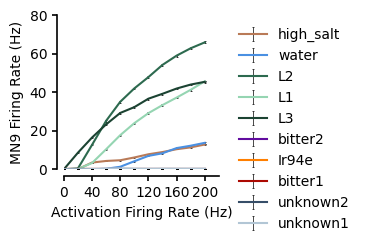

In [20]:
colors_wanted = list(dict.fromkeys(labial_cluster.color))
type_name = list(dict.fromkeys(labial_cluster.type))

df_mn9 = pd.concat(list(df_mn9_per_type_labial.values()))
std_mn9 = pd.concat(list(std_per_type_labial.values()))
df_mn9.index = list(df_mn9_per_type_labial.keys())
std_mn9.index = list(std_per_type_labial.keys())

df_mn9 = df_mn9.drop('L1+L2+L3')
std_mn9 = std_mn9.drop('L1+L2+L3')
colors = [colors_wanted[type_name.index(g)] for g in df_mn9.index]


fig, ax = plt.subplots(1,1, figsize=(2,2))

for i, g in enumerate(df_mn9.index):

    y = df_mn9.loc[g].values.astype(float)

    # 에러 계산 방법 선택
    yerr = std_mn9.loc[g].values

    ax.errorbar(
        df_mn9.columns,
        y,
        yerr=yerr,                 # 실제 에러가 있다면 여기에
        color=colors[i],
        capsize=1,
        ecolor='black',
        label=g,
        elinewidth=.5,
        capthick=.5,
#         linewidth=1
    )

ax.set_ylim([0,80])
ax.set_xlim([0,10])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.tick_params(axis='both', width=1.2)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_linewidth(1.2)
ax.set_xticks(list(range(0,11,2)), list(range(0,240,40)))
ax.set_xlabel('Activation Firing Rate (Hz)')
ax.set_ylabel('MN9 Firing Rate (Hz)')
ax.legend(loc=2,bbox_to_anchor=(1.05,1),frameon=False)
ax.set_xlim([0,11])


In [16]:
df_mn9

exp_name,0Hz,20Hz,40Hz,60Hz,80Hz,100Hz,120Hz,140Hz,160Hz,180Hz,...,120Hz_0Hz,120Hz_160Hz,140Hz_0Hz,140Hz_160Hz,160Hz_0Hz,160Hz_160Hz,180Hz_0Hz,180Hz_160Hz,200Hz_0Hz,200Hz_160Hz
high_salt,0.0,0.105,3.505,4.335,4.700,6.145,7.810,8.960,10.440,11.390,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
water,0.0,0.000,0.000,0.270,1.315,4.180,6.965,8.315,11.020,12.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L2,0.0,0.460,12.690,25.185,35.065,42.020,47.885,54.235,59.040,62.870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1,0.0,0.085,3.270,10.405,17.720,23.960,29.160,33.360,37.240,41.295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L3,0.0,8.635,16.500,23.335,29.270,32.290,36.680,39.220,41.945,44.010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bitter2,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ir94e,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bitter1,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unknown2,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unknown1,0.0,0.000,0.100,0.370,0.505,0.325,0.265,0.330,0.315,0.305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
